# **E-Commerce Purchase Prediction**

> Predicting session-level purchase behavior using ensemble machine learning

## Project Overview

**Business Problem:** Predict whether an e-commerce session will result in a purchase, enabling targeted marketing and inventory optimization.

**Approach:** Ensemble of tree-based models (Random Forest + XGBoost) with systematic feature engineering and hyperparameter tuning.

**Key Results:**
- Final F1-Score: **0.75178** (top 15% on leaderboard)
- Handled class imbalance (35% positive rate)
- Minimal feature engineering (only missingness indicator) - let models learn
- Optimal probability threshold tuning: 0.519

## Data Preparation

### Load Packages

In [ ]:
import sys
print(f"Python version: {sys.version}")

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]


In [ ]:
!pip install kaggle

# UPLOAD YOUR kaggle.json FILE
from google.colab import files
uploaded = files.upload()  # Click "Choose Files" and select your kaggle.json

# Copy it to the correct location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Verify it's there
!ls -la ~/.kaggle/

# Dwnload the competition data
!kaggle competitions download -c dsba-m-2-challenge-purchase-prediction

# Unzip
!unzip dsba-m-2-challenge-purchase-prediction.zip

In [ ]:
ls

dsba-m-2-challenge-purchase-prediction.zip  sample_data/
kaggle.json                                 test_dataset_M2_with_id.csv
metadata_V2.txt                             train_dataset_M2_with_id.csv


In [ ]:
with open('metadata_V2.txt', 'r') as f:
  metadata = f.read()
  print(metadata)


Target: Purchase

Note on campaign timing: The Company has done two marketing campaigns, between days 25 and 50 (inclusive) and 75 and 90 (inclusive).
- Campaign_Period == TRUE when Day ∈ [25, 50] or Day ∈ [75, 90].

Columns
-------
Purchase: int {0,1}. 1 = purchase, 0 = no purchase.

Age: int, ~18–65. User’s age.

Gender: int {0,1}. Binary gender flag. 0 = male, 1 = female.

Reviews_Read: int ≥0. Count of product reviews viewed in session.

Price: numeric ≥0. Listed product price (euros).

Discount: int [0–100]. Percentage discount on Price.

Category: int {0,1,2,3,4}. Product category code.

Items_In_Cart: int ≥0. Number of items present in the cart during session.

Time_of_Day: factor {morning, afternoon, evening}. Session time bucket.

Email_Interaction: int {0,1}. 1 if the user interacted with a marketing email in this session, or in the recorded past.

Device_Type: factor {Mobile, Desktop, Tablet}. Access device for the session.

Payment_Method: string. Reported historic payment

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 000

### Data Inspection

In [ ]:
train_df = pd.read_csv('train_dataset_M2_with_id.csv')

print(f"Training data shape: {train_df.shape}")
# print(f"\nColumn names: {train_df.columns.tolist()}")
print(f"\nData types:\n {train_df.dtypes}")
print(f"\n Bastic statistics:\n {train_df.describe()}")
print(f"\nMissing values:\n {train_df.isnull().sum()}")

Training data shape: (13731, 22)

Data types:
 id                              int64
Age                           float64
Gender                        float64
Reviews_Read                  float64
Price                         float64
Discount                      float64
Category                      float64
Items_In_Cart                 float64
Time_of_Day                    object
Email_Interaction             float64
Device_Type                    object
Payment_Method                 object
Referral_Source                object
Socioeconomic_Status_Score    float64
Engagement_Score              float64
AB_Bucket                     float64
Price_Sine                    float64
PM_RS_Combo                    object
Session_ID                     object
Day                             int64
Campaign_Period                object
Purchase                        int64
dtype: object

 Bastic statistics:
                  id           Age        Gender  Reviews_Read         Price  \
co

In [ ]:
# Check class balances
print(f"Number of purchases: {np.sum(train_df['Purchase'] == 1)}")
print(f"Purchase class ratio: {np.mean(train_df['Purchase'] == 1):.2f}")

Number of purchases: 4796
Purchase class ratio: 0.35


In [ ]:
pd.set_option('display.max_columns', None)
train_df.sample(5)

,id,Age,Gender,Reviews_Read,Price,Discount,Category,Items_In_Cart,Time_of_Day,Email_Interaction,Device_Type,Payment_Method,Referral_Source,Socioeconomic_Status_Score,Engagement_Score,AB_Bucket,Price_Sine,PM_RS_Combo,Session_ID,Day,Campaign_Period,Purchase
13049,13050,21.0,1.0,3.0,939.298,41.0,2.0,7.0,evening,1.0,Tablet,NaN,Search_engine,4.00,3.828084,0.0,0.940416,PayPal:Search_engine,S0019040,55,False,0
13440,13441,35.0,1.0,1.0,446.090,37.0,3.0,0.0,morning,1.0,Mobile,Bank,Social_media,6.12,0.982148,6.0,-0.342863,Bank:Social_media,S0019592,7,False,0
13286,13287,18.0,1.0,2.0,835.230,49.0,1.0,1.0,evening,1.0,Desktop,Cash,Ads,1.06,1.737904,3.0,0.661054,Cash:Ads,S0019372,25,True,1
1202,1203,22.0,0.0,3.0,807.236,10.0,3.0,13.0,morning,NaN,Mobile,Cash,Search_engine,1.33,4.112827,2.0,0.760542,Cash:Search_engine,S0001773,18,False,0
8102,8103,24.0,0.0,4.0,229.822,43.0,3.0,4.0,evening,1.0,Mobile,PayPal,Email,1.44,2.302089,3.0,0.200157,PayPal:Email,S0011812,57,False,0


### Data Recovery

In [ ]:
# Clean features
train_df['Time_of_Day'] = train_df['Time_of_Day'].str.lower().str.replace('0','o')
train_df['Payment_Method'] = train_df['Payment_Method'].str.lower().str.replace('_','').str.replace(' ','')
train_df['Referral_Source'] = train_df['Referral_Source'].str.strip().str.lower().str.replace('0','o').str.replace('_','').str.replace('-','')
train_df['PM_RS_Combo'] = train_df['PM_RS_Combo'].str.strip().str.lower().str.replace('0','o').str.replace('_','').str.replace('-','')

In [ ]:
# Data recovery of missing values

train_df[['PM_extracted', 'RS_extracted']] = train_df['PM_RS_Combo'].str.split(':', expand=True)

# Map variations to standard names
payment_mapping = {'pay_pal': 'paypal', 'bank_transfer': 'bank', 'banktransfer': 'bank'}

train_df['Payment_Method'] = train_df['Payment_Method'].replace(payment_mapping)
train_df['PM_extracted'] = train_df['PM_extracted'].replace(payment_mapping)

# Verify consistency before filling
mask_both_PM = train_df['Payment_Method'].notna() & train_df['PM_extracted'].notna()
matches_PM = (train_df.loc[mask_both_PM, 'Payment_Method'] == train_df.loc[mask_both_PM, 'PM_extracted']).sum()
total_PM = mask_both_PM.sum()

mask_both_RS = train_df['Referral_Source'].notna() & train_df['RS_extracted'].notna()
matches_RS = (train_df.loc[mask_both_RS, 'Referral_Source'] == train_df.loc[mask_both_RS, 'RS_extracted']).sum()
total_RS = mask_both_RS.sum()

print(f"Payment method matches before fillna: {matches_PM}/{total_PM} ({matches_PM/total_PM*100:.2f}%)")
print(f"Referral source matches before fillna: {matches_RS}/{total_RS} ({matches_RS/total_RS*100:.2f}%)")

Payment method matches before fillna: 11181/11461 (97.56%)
Referral source matches before fillna: 11316/11490 (98.49%)


In [ ]:
# Fill missing values
train_df['Payment_Method'] = train_df['Payment_Method'].fillna(train_df['PM_extracted'])
train_df['Referral_Source'] = train_df['Referral_Source'].fillna(train_df['RS_extracted'])

# Verify consistency after filling
mask_both_PM = train_df['Payment_Method'].notna() & train_df['PM_extracted'].notna()
matches_PM = (train_df.loc[mask_both_PM, 'Payment_Method'] == train_df.loc[mask_both_PM, 'PM_extracted']).sum()
total_PM = mask_both_PM.sum()

mask_both_RS = train_df['Referral_Source'].notna() & train_df['RS_extracted'].notna()
matches_RS = (train_df.loc[mask_both_RS, 'Referral_Source'] == train_df.loc[mask_both_RS, 'RS_extracted']).sum()
total_RS = mask_both_RS.sum()

# Drop duplicate columns
train_df.drop(columns=['PM_RS_Combo', 'PM_extracted', 'RS_extracted'], inplace=True)

print(f"Payment method matches after fillna: {matches_PM}/{total_PM} ({matches_PM/total_PM*100:.2f}%)")
print(f"Referral source matches after fillna: {matches_RS}/{total_RS} ({matches_RS/total_RS*100:.2f}%)")

Payment method matches after fillna: 13183/13463 (97.92%)
Referral source matches after fillna: 13289/13463 (98.71%)


### Category & Numeric Features

In [ ]:
# Category features

categorical_cols = [
    'Gender',
    'Time_of_Day',
    'Email_Interaction',
    'Device_Type',
    'Payment_Method',
    'Referral_Source',
    'Category',
    'AB_Bucket',
    'Campaign_Period'
]

# Convert dtypes
for col in categorical_cols:
    if col in train_df.columns:
        train_df[col] = train_df[col].astype('category')


category = train_df.select_dtypes(include='category')
category.describe()

,Gender,Category,Time_of_Day,Email_Interaction,Device_Type,Payment_Method,Referral_Source,AB_Bucket,Campaign_Period
count,13464.0,13438.0,13440,13462.0,13451,13687,13700,13449.0,13459
unique,2.0,5.0,3,2.0,3,4,5,7.0,2
top,0.0,1.0,evening,0.0,Mobile,paypal,searchengine,6.0,False
freq,6807.0,2779.0,5348,7336.0,6100,3534,2790,1942.0,8501


In [ ]:
# Numeric features
numeric = train_df[train_df.select_dtypes(include=np.number).columns].iloc[:,1:]
numeric.describe()

,Age,Reviews_Read,Price,Discount,Items_In_Cart,Socioeconomic_Status_Score,Engagement_Score,Price_Sine,Day,Purchase
count,11628.000000,13440.000000,13092.000000,13457.000000,13468.000000,13455.000000,13472.000000,13460.000000,13731.000000,13731.000000
mean,31.994324,2.982292,560.285025,25.156053,3.516409,5.128119,2.264343,0.009075,35.406890,0.349283
std,12.932543,1.723886,758.374782,14.952089,2.858477,3.454127,1.445185,0.707527,20.291556,0.476761
min,18.000000,0.000000,5.127000,0.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000
25%,22.000000,2.000000,254.374750,12.000000,1.000000,2.530000,1.067041,-0.702264,18.000000,0.000000
50%,28.000000,3.000000,499.336500,25.000000,3.000000,4.540000,2.108914,0.033180,36.000000,0.000000
75%,39.000000,4.000000,751.216500,38.000000,5.000000,7.140000,3.325269,0.705888,53.000000,1.000000
max,65.000000,11.000000,14988.319963,90.000000,28.000000,22.340000,6.398595,1.000000,70.000000,1.000000


## Exploratory Data Analysis (EDA)

### Data Visualization

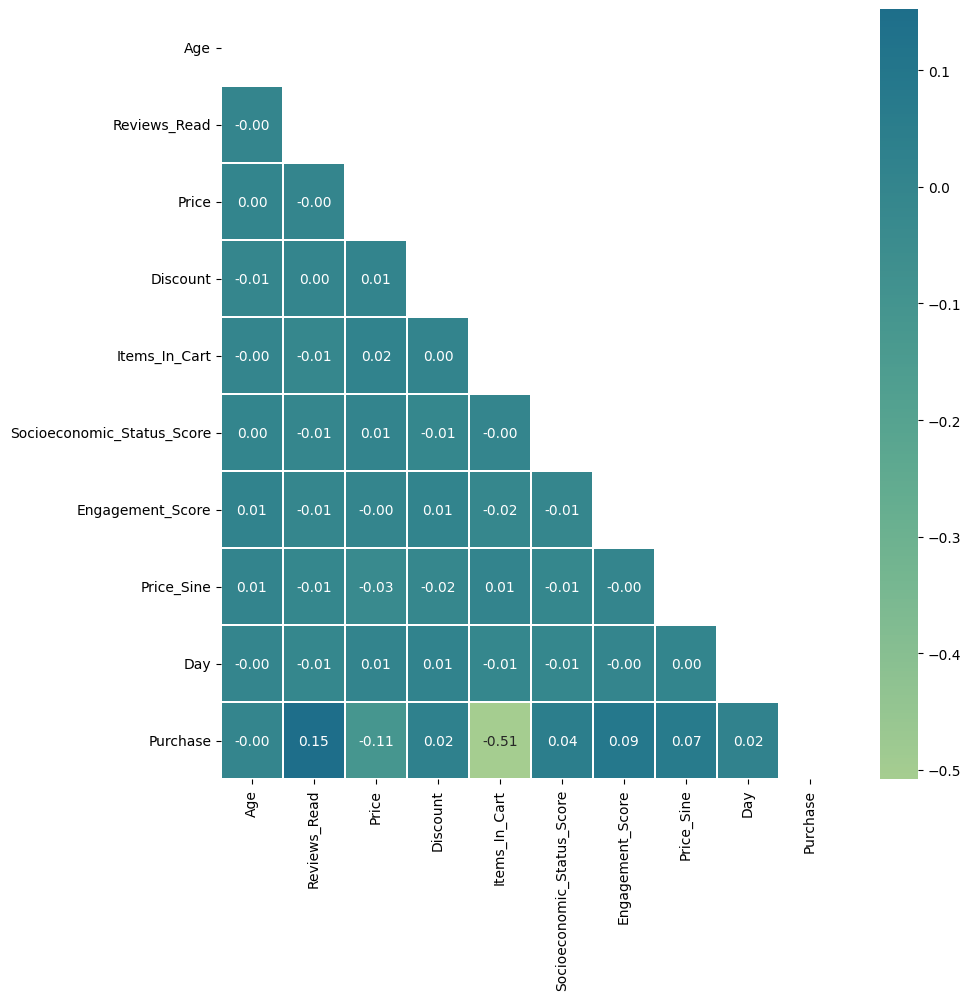

In [ ]:
# Plot the correlation

corr = numeric.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 10))
ax = sns.heatmap(corr, mask=mask, center=0, cmap='crest', linewidths=.1, annot=True, fmt=".2f")
# plt.savefig('heatmap.png')
plt.show()

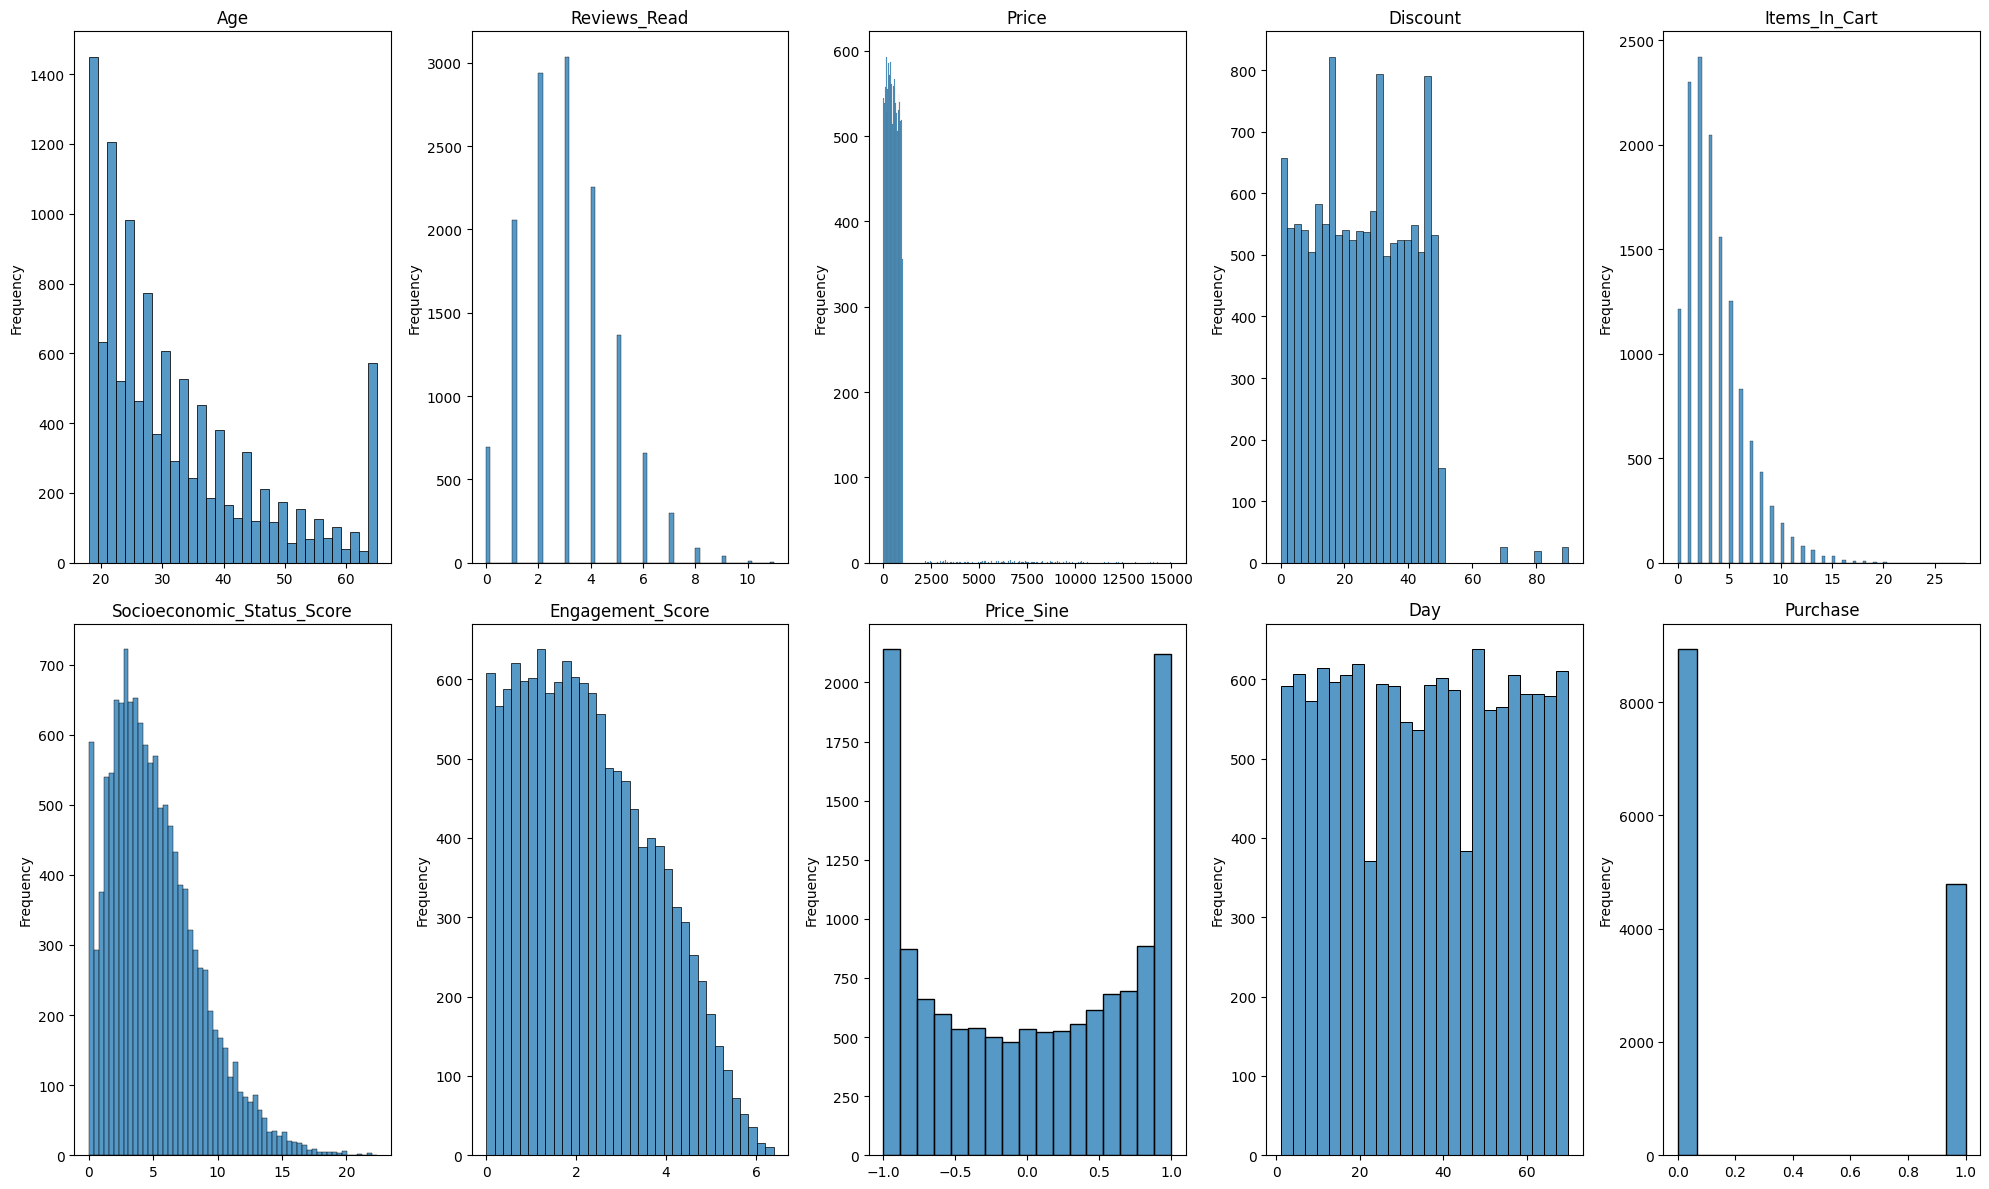

In [ ]:
# Histograms

fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(20,12))
ax = ax.flatten()

for i, col in enumerate(numeric.columns):
  sns.histplot(numeric[col], ax=ax[i])
  ax[i].set_title(col)
  ax[i].set_xlabel('')
  ax[i].set_ylabel('Frequency')

plt.tight_layout()
# plt.savefig('histograms.png')
plt.show()

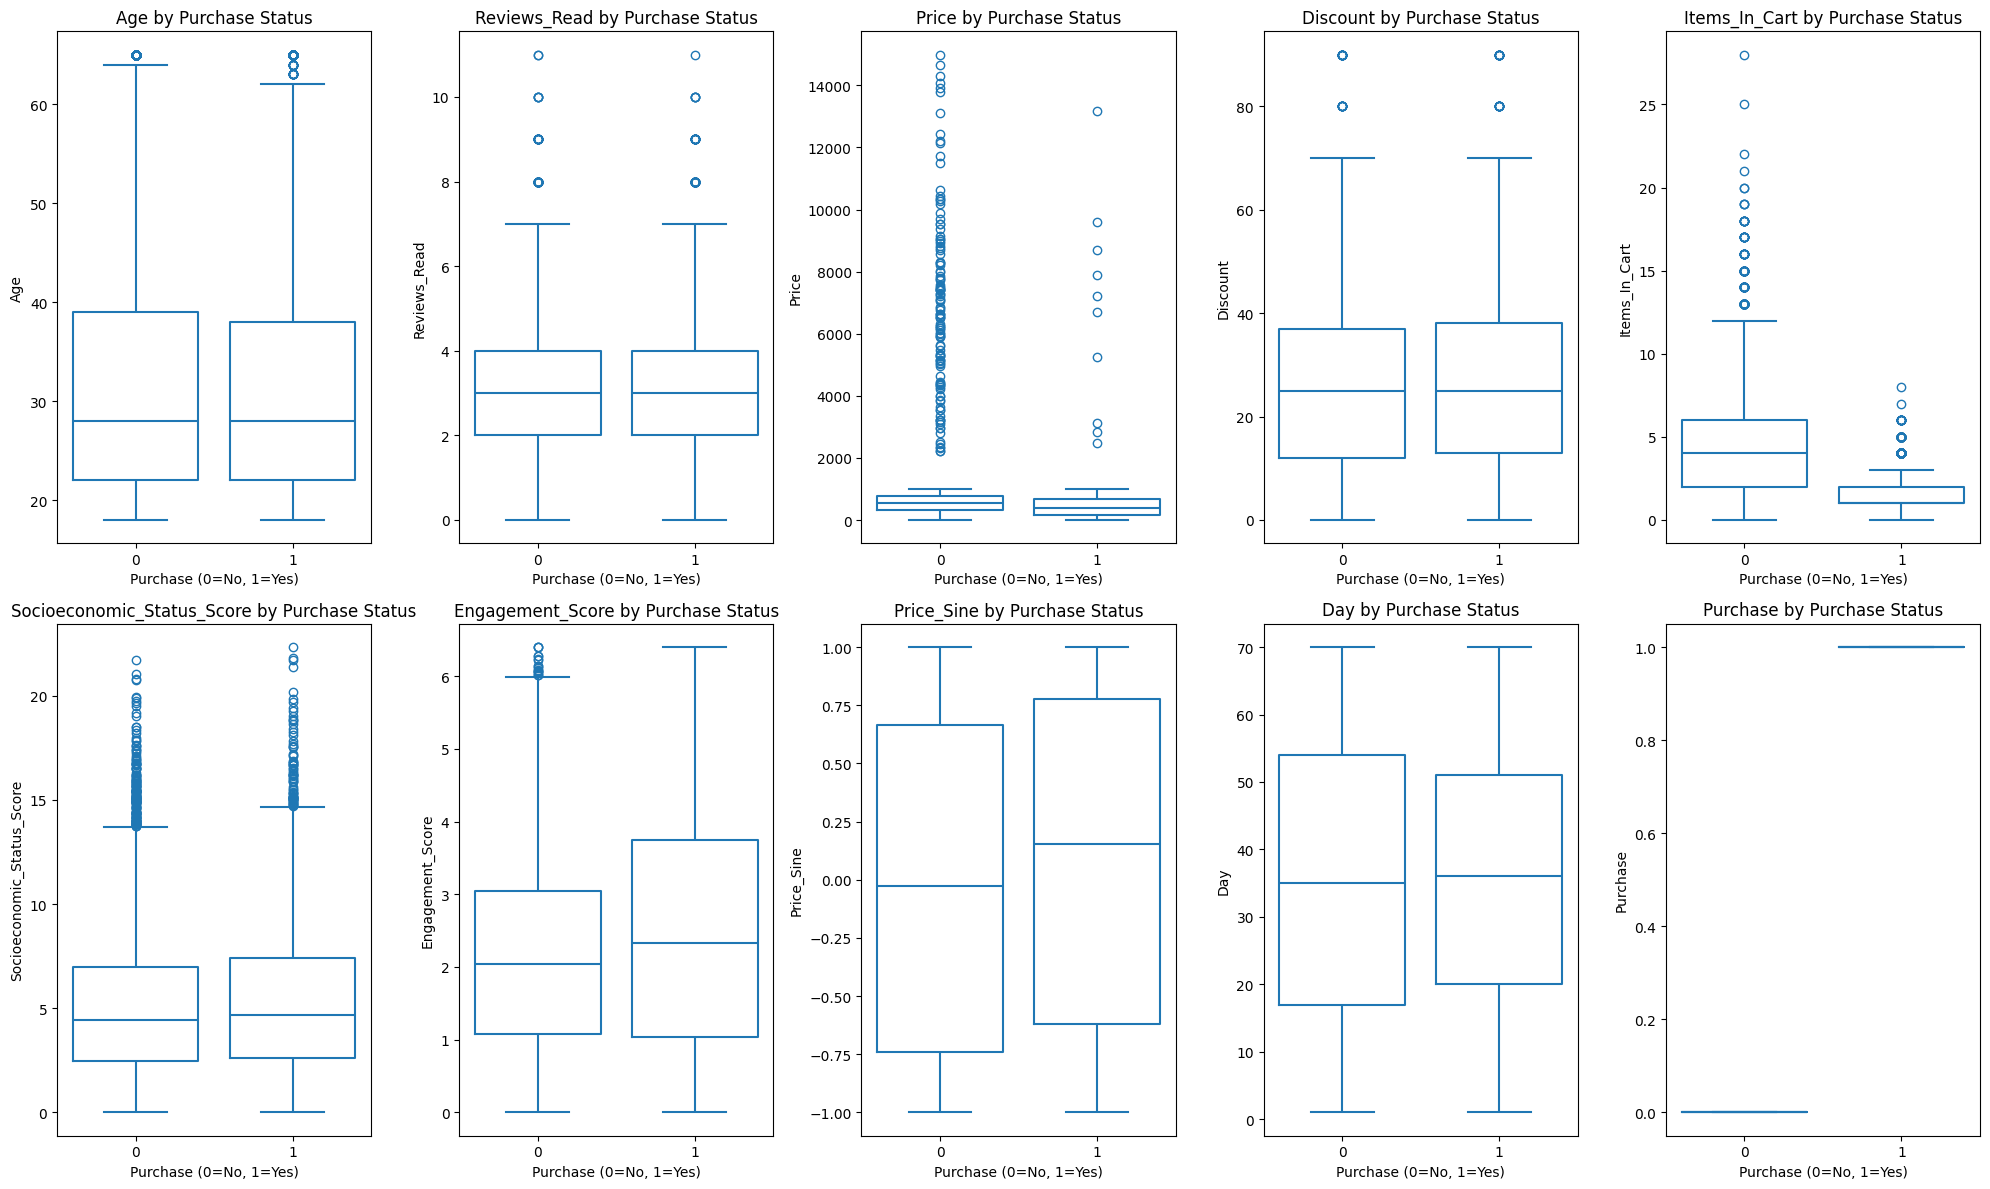

In [ ]:
# Box plots

fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(20,12))
ax = ax.flatten()

for i, col in enumerate(numeric.columns):
  sns.boxplot(data=train_df, x='Purchase', y=numeric[col], ax=ax[i], fill=False)
  ax[i].set_title(f'{col} by Purchase Status')
  ax[i].set_xlabel('Purchase (0=No, 1=Yes)')
  ax[i].set_ylabel(col)

plt.tight_layout()
# plt.savefig('boxplots.png')
plt.show()

#### Findings from EDA

1. Most features are weakly correlated with `Purchase`, except `Items_In_Cart` (≈ −0.51).
2. Several numeric features are heavily right-skewed (`Price`, `Items_In_Cart`, `Engagement_Score`, `Socioeconomic_Status_Score`).
3. `Day` behaves like a uniform/random variable.
4. Compared by class:
   - Purchasers have higher `Engagement_Score`, slightly higher `Price_Sine` and `Socioeconomic_Status_Score`.
   - Purchasers have lower `Items_In_Cart` on average.

### Feature Understanding

#### `Price_Sine`

- No correlation with `Price` (unexpected for a transformed feature)
- Statistical distributions similar across classes except slight differences at mean and median
- No interpretable patterns observed in pairplots

➝ Likely noise feature, kept only for completeness.

Price_Sine Investigation

1. Summary Statistics:
              Price    Price_Sine
count  13092.000000  13460.000000
mean     560.285025      0.009075
std      758.374782      0.707527
min        5.127000     -1.000000
25%      254.374750     -0.702264
50%      499.336500      0.033180
75%      751.216500      0.705888
max    14988.319963      1.000000

2. Testing mathematical relationships:
Correlation with sin(price_normalized): -0.0754

3. Relationship with target:
           count      mean       std  min       25%       50%       75%  \
Purchase                                                                  
0         8761.0 -0.026280  0.705915 -1.0 -0.739927 -0.028254  0.663135   
1         4699.0  0.074994  0.705884 -1.0 -0.621521  0.155679  0.775735   

               max  
Purchase            
0         1.000000  
1         0.999999  

4. Pairplots


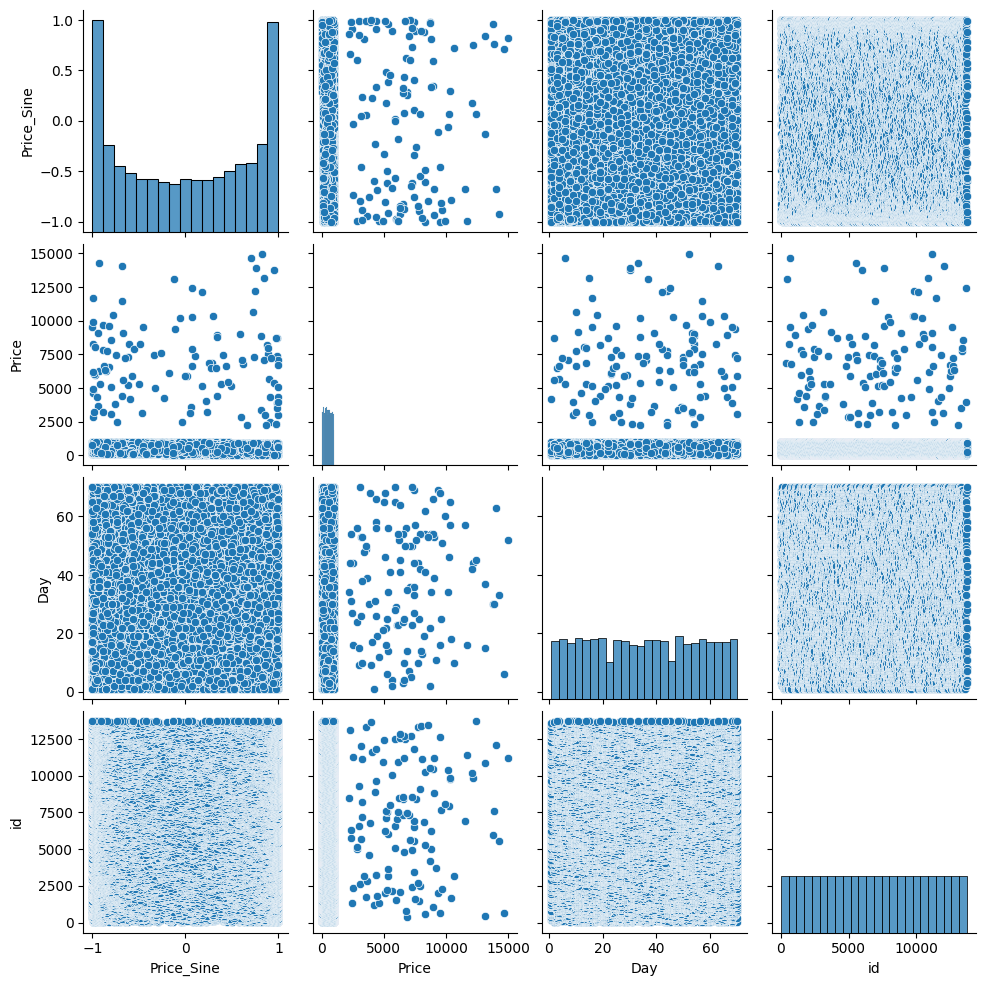

In [ ]:
# Investigate 'Price_Sine'

print("="*50)
print("Price_Sine Investigation")
print("="*50)

# 1. Basic stats
print("\n1. Summary Statistics:")
print(train_df[['Price', 'Price_Sine']].describe())

# 2. Check for formula relationship
print("\n2. Testing mathematical relationships:")
price_norm = (train_df['Price'] - train_df['Price'].mean()) / train_df['Price'].std()
print(f"Correlation with sin(price_normalized): {train_df['Price_Sine'].corr(np.sin(price_norm)):.4f}")

# 3. Check relationship with Purchase
print(f"\n3. Relationship with target:")
print(train_df.groupby('Purchase')['Price_Sine'].describe())

print(f"\n4. Pairplots")
sns.pairplot(train_df[['Price_Sine', 'Price', 'Day', 'id']], diag_kind='hist')

#### `Campaign_Period` (Chi-square test)

**Question:** Does `Campaign_Period` influence purchase rate?

**Hypotheses:**
- H₀: `Campaign_Period` has no effect on `Purchase`
- H₁: `Campaign_Period` affects `Purchase`

**Results:**
- Chi-square test rejects H₀
- `Campaign_Period` shows significance conditional on `AB_Bucket`

In [ ]:
# Investigate 'AB_Bucket'

train_stat = train_df[['AB_Bucket','Campaign_Period','Purchase']].astype(float)
interaction_check = train_stat.groupby(['AB_Bucket', 'Campaign_Period'])['Purchase'].mean()
print('\nPurchase rate by AB_Bucket x Campaign_Period:\n')
print(interaction_check.unstack())


Purchase rate by AB_Bucket x Campaign_Period:

Campaign_Period       0.0       1.0
AB_Bucket                          
0.0              0.309322  0.399721
1.0              0.307107  0.397661
2.0              0.310374  0.413940
3.0              0.314597  0.446532
4.0              0.309329  0.384962
5.0              0.326050  0.422156
6.0              0.311973  0.422652


In [ ]:
from scipy.stats import chi2_contingency

# Chi-square test for AB_Bucket × Campaign_Period interaction
contingency_table = pd.crosstab(
    [train_stat['AB_Bucket'], train_stat['Campaign_Period']],
    train_stat['Purchase']
)

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-square: {chi2:.4f}")
print(f"P-value: {p_value}")
print(f"Result: {'Significant' if p_value < 0.05 else 'Not significant'}")

Chi-square: 143.5990
P-value: 3.994071942652955e-24
Result: Significant


## Model Pipeline

### Preprocessing

In [ ]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, classification_report

In [ ]:
# Step 1
# Load data
train_df = pd.read_csv('train_dataset_M2_with_id.csv')
test_df = pd.read_csv('test_dataset_M2_with_id.csv')

# Creat missingness flag - feature engineering 1
train_df['Age_missing'] = train_df['Age'].isna().astype(int)
test_df['Age_missing'] = test_df['Age'].isna().astype(int)

# Clean category features
train_df['Time_of_Day'] = train_df['Time_of_Day'].str.lower().str.replace('0','o')
train_df['Payment_Method'] = train_df['Payment_Method'].str.lower().str.replace('_','').str.replace(' ','')
train_df['Referral_Source'] = train_df['Referral_Source'].str.strip().str.lower().str.replace('0','o').str.replace('_','').str.replace('-','')
train_df['PM_RS_Combo'] = train_df['PM_RS_Combo'].str.strip().str.lower().str.replace('0','o').str.replace('_','').str.replace('-','')

test_df['Time_of_Day'] = test_df['Time_of_Day'].str.lower().str.replace('0','o')
test_df['Payment_Method'] = test_df['Payment_Method'].str.lower().str.replace('_','').str.replace(' ','')
test_df['Referral_Source'] = test_df['Referral_Source'].str.strip().str.lower().str.replace('0','o').str.replace('_','').str.replace('-','')
test_df['PM_RS_Combo'] = test_df['PM_RS_Combo'].str.strip().str.lower().str.replace('0','o').str.replace('_','').str.replace('-','')

In [ ]:
# Step 2
# Data recovery of missing values
train_df[['PM_extracted', 'RS_extracted']] = train_df['PM_RS_Combo'].str.split(':', expand=True)
test_df[['PM_extracted', 'RS_extracted']] = test_df['PM_RS_Combo'].str.split(':', expand=True)

# Map variations to standard names
payment_mapping = {'pay_pal': 'paypal', 'bank_transfer': 'bank', 'banktransfer': 'bank'}

train_df['Payment_Method'] = train_df['Payment_Method'].replace(payment_mapping)
train_df['PM_extracted'] = train_df['PM_extracted'].replace(payment_mapping)
test_df['Payment_Method'] = test_df['Payment_Method'].replace(payment_mapping)
test_df['PM_extracted'] = test_df['PM_extracted'].replace(payment_mapping)

# Fill missing values
train_df['Payment_Method'] = train_df['Payment_Method'].fillna(train_df['PM_extracted'])
train_df['Referral_Source'] = train_df['Referral_Source'].fillna(train_df['RS_extracted'])
test_df['Payment_Method'] = test_df['Payment_Method'].fillna(test_df['PM_extracted'])
test_df['Referral_Source'] = test_df['Referral_Source'].fillna(test_df['RS_extracted'])

# Drop duplicate columns
train_df.drop(columns=['PM_RS_Combo', 'PM_extracted', 'RS_extracted'], inplace=True)
test_df.drop(columns=['PM_RS_Combo', 'PM_extracted', 'RS_extracted'], inplace=True)

In [ ]:
# Step 3
# Category features

cat_cols = [
    'Gender',
    'Time_of_Day',
    'Email_Interaction',
    'Device_Type',
    'Payment_Method',
    'Referral_Source',
    'Category',
    'AB_Bucket',
    'Campaign_Period'
]

# Fill categorical with 'Unknown'
for col in cat_cols:
    train_df[col] = train_df[col].fillna('Unknown')
    test_df[col] = test_df[col].fillna('Unknown')


# Numeric features
# Fill numerical with median from train to split missing as distinct group
num_cols = [
    'Age',
    'Reviews_Read',
    'Price',
    'Discount',
    'Items_In_Cart',
    'Socioeconomic_Status_Score',
    'Engagement_Score',
    'Price_Sine',
    'Day',

]

for col in num_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())
    test_df[col] = test_df[col].fillna(train_df[col].median())

In [ ]:
# Step 4
# Encode Categorical Variables
# OneHotEncoder

for col in cat_cols:
    train_df[col] = train_df[col].astype(str)
    test_df[col] = test_df[col].astype(str)

# Fit OHE on train only, transform both
ohe = OneHotEncoder(categories='auto', handle_unknown='ignore', sparse_output=False)
ohe.fit(train_df[cat_cols])

train_ohe = ohe.transform(train_df[cat_cols])
test_ohe = ohe.transform(test_df[cat_cols])

# Convert to DataFrame
ohe_cols = ohe.get_feature_names_out(cat_cols)

train_ohe_df = pd.DataFrame(train_ohe, columns=ohe_cols, index=train_df.index)
test_ohe_df  = pd.DataFrame(test_ohe, columns=ohe_cols, index=test_df.index)

# Drop original categorical columns
train_df = pd.concat([train_df.drop(columns=cat_cols), train_ohe_df], axis=1)
test_df  = pd.concat([test_df.drop(columns=cat_cols),  test_ohe_df], axis=1)

### Model Training

In [ ]:
# Step 5
# Baseline Random Forest

feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X = train_df[feature_cols]
y = train_df['Purchase']

# Baseline model
rf_clf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

In [ ]:
def run_clf(X, y, clf, test_size=0.2, random_state=SEED):

  # Train-test split for validation
  X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size,
                              random_state=random_state, stratify=y)

  # Train
  clf.fit(X_train, y_train)

  # Validate
  y_pred_train = clf.predict(X_train)
  y_pred = clf.predict(X_val)
  y_pred_train_proba = clf.predict_proba(X_train)[:,1]
  y_pred_proba = clf.predict_proba(X_val)[:,1]

  print("\n=== Train F1 ===")
  print(f"\nTrain F1-Score:  {f1_score(y_train, y_pred_train):.4f}")

  print("\n=== Baseline Random Forest Results ===")
  print("Classification report train:")
  print(classification_report(y_train, y_pred_train, labels=np.unique(y)))
  print("Classification report val:")
  print(classification_report(y_val, y_pred, labels=np.unique(y)))

  print("\n=== Cross-validation F1 ===")
  cv_scores = cross_val_score(clf, X, y, cv=5, scoring='f1', n_jobs=-1)
  print(f"\n5-Fold CV F1-Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

  print("\n=== Prediction probability ===")
  print(f"\nTrain: {y_pred_train_proba}")
  print(f"\nVal: {y_pred_proba}")

In [ ]:
run_clf(X, y, rf_clf)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    2.8s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.2s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.1s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.



=== Train F1 ===

Train F1-Score:  0.8179

=== Baseline Random Forest Results ===
Classification report train:
              precision    recall  f1-score   support

           0       0.95      0.82      0.88      7147
           1       0.73      0.92      0.82      3837

    accuracy                           0.86     10984
   macro avg       0.84      0.87      0.85     10984
weighted avg       0.88      0.86      0.86     10984

Classification report val:
              precision    recall  f1-score   support

           0       0.92      0.79      0.85      1788
           1       0.69      0.87      0.77       959

    accuracy                           0.82      2747
   macro avg       0.81      0.83      0.81      2747
weighted avg       0.84      0.82      0.82      2747


=== Cross-validation F1 ===


[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    0.0s finished



5-Fold CV F1-Score: 0.7772 (+/- 0.0055)

=== Prediction probability ===

Train: [0.42884096 0.63290921 0.5869818  ... 0.17816523 0.70863197 0.40093262]

Val: [0.71710349 0.60705965 0.23610988 ... 0.54505423 0.15531449 0.36243167]



Top 15 Important Features:
                       feature  importance
4                Items_In_Cart    0.586105
2                        Price    0.085296
6             Engagement_Score    0.066142
1                 Reviews_Read    0.040794
7                   Price_Sine    0.022407
17       Email_Interaction_0.0    0.021132
5   Socioeconomic_Status_Score    0.017781
8                          Day    0.016497
18       Email_Interaction_1.0    0.016476
3                     Discount    0.014609
21          Device_Type_Mobile    0.011774
49       Campaign_Period_False    0.011100
0                          Age    0.010805
50        Campaign_Period_True    0.010680
38                Category_3.0    0.008179


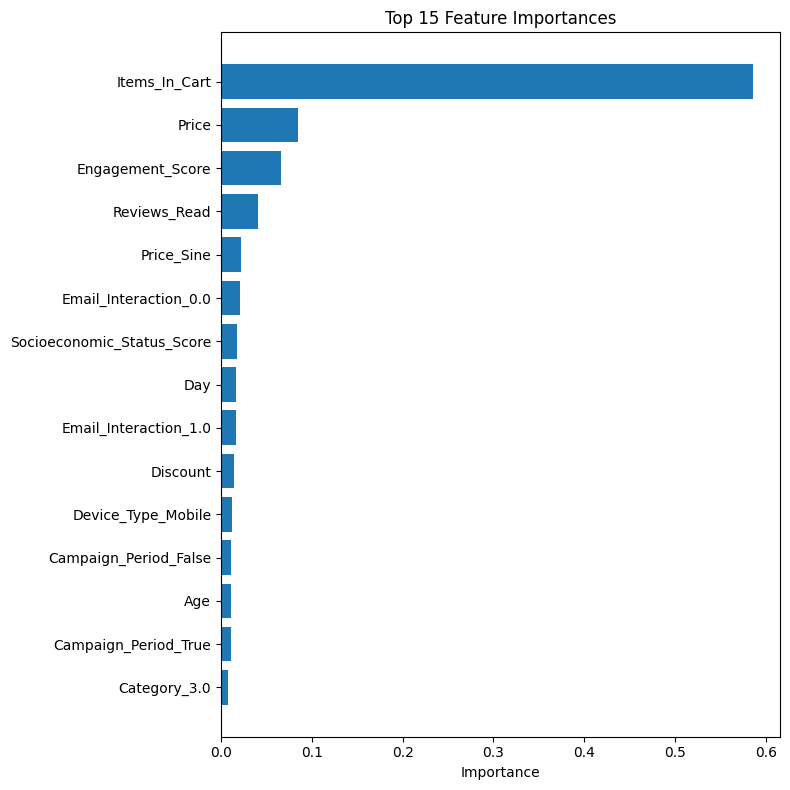

In [ ]:
# Step 6
# Feature importances

# Get feature importances
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Important Features:")
print(feature_importance.head(15))

# Visualize
plt.figure(figsize=(8, 8))
plt.barh(feature_importance.head(15)['feature'], feature_importance.head(15)['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Random Forest



### Overfitting - Baseline Random Forest (0.67632)

In [ ]:
# Baseline model
rf_final = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1,
)

# Fit on all training data
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X_full = train_df[feature_cols]
y_full = train_df['Purchase']
rf_final.fit(X_full, y_full)

# Prepare test features (same columns as training)
X_test = test_df[feature_cols]

# Make predictions on test
test_predictions = rf_final.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'Purchase': test_predictions
})

# Save to CSV
submission.to_csv('submission.csv', index=False)

# Verify format
print(submission.head())
print(f"Shape: {submission.shape}")
print(f"Columns: {submission.columns.tolist()}")

   id  Purchase
0   1         0
1   2         1
2   3         0
3   4         1
4   5         0
Shape: (6269, 2)
Columns: ['id', 'Purchase']


In [ ]:
# Verify no missing values in submission
print(submission.isnull().sum())
print(submission['Purchase'].value_counts())

id          0
Purchase    0
dtype: int64
Purchase
0    3347
1    2922
Name: count, dtype: int64


#### Overfitting - Hyperparameter Tuning (0.68536)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# Expanded parameter grid
param_dist = {
    'n_estimators': [200, 300, 500],
    'max_depth': [10, 15, 20, 25],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 20, 30],
    'max_features': ['sqrt', 'log2', 0.5],
    'class_weight': ['balanced_subsample', None]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='f1',
    random_state=SEED,
    n_jobs=-1,
    verbose=2
)

rf_search.fit(X_full, y_full)

print(f"Best params: {rf_search.best_params_}")
print(f"Best CV F1: {rf_search.best_score_:.4f}")

# Use best model
best_rf = rf_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'n_estimators': 300, 'min_samples_split': 20, 'min_samples_leaf': 20, 'max_features': 0.5, 'max_depth': 10, 'class_weight': 'balanced_subsample'}
Best CV F1: 0.7727


### Exp1: Feature Engineering yes/no - Baseline Random Forest (0.72618)

#### Test

In [ ]:
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X = train_df[feature_cols]
y = train_df['Purchase']

# Baseline model
rf_exp = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=20,
    max_features=0.5,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1,
)

In [ ]:
run_clf(X, y, rf_exp)


=== Train F1 ===

Train F1-Score:  0.8200

=== Baseline Random Forest Results ===
Classification report train:
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      7147
           1       0.75      0.90      0.82      3837

    accuracy                           0.86     10984
   macro avg       0.85      0.87      0.85     10984
weighted avg       0.87      0.86      0.86     10984

Classification report val:
              precision    recall  f1-score   support

           0       0.91      0.81      0.85      1788
           1       0.70      0.85      0.77       959

    accuracy                           0.82      2747
   macro avg       0.80      0.83      0.81      2747
weighted avg       0.84      0.82      0.82      2747


=== Cross-validation F1 ===

5-Fold CV F1-Score: 0.7802 (+/- 0.0082)

=== Prediction probability ===

Train: [0.31419528 0.61818403 0.55454153 ... 0.04439009 0.83796375 0.26746571]

Val: [0.80859945 0.70521


Top 15 Important Features:
                       feature  importance
4                Items_In_Cart    0.641047
2                        Price    0.093141
6             Engagement_Score    0.074147
1                 Reviews_Read    0.037215
17       Email_Interaction_0.0    0.019726
21          Device_Type_Mobile    0.015940
7                   Price_Sine    0.015896
18       Email_Interaction_1.0    0.014619
50        Campaign_Period_True    0.013435
8                          Day    0.012045
5   Socioeconomic_Status_Score    0.011266
3                     Discount    0.008367
49       Campaign_Period_False    0.008010
38                Category_3.0    0.005550
0                          Age    0.005234


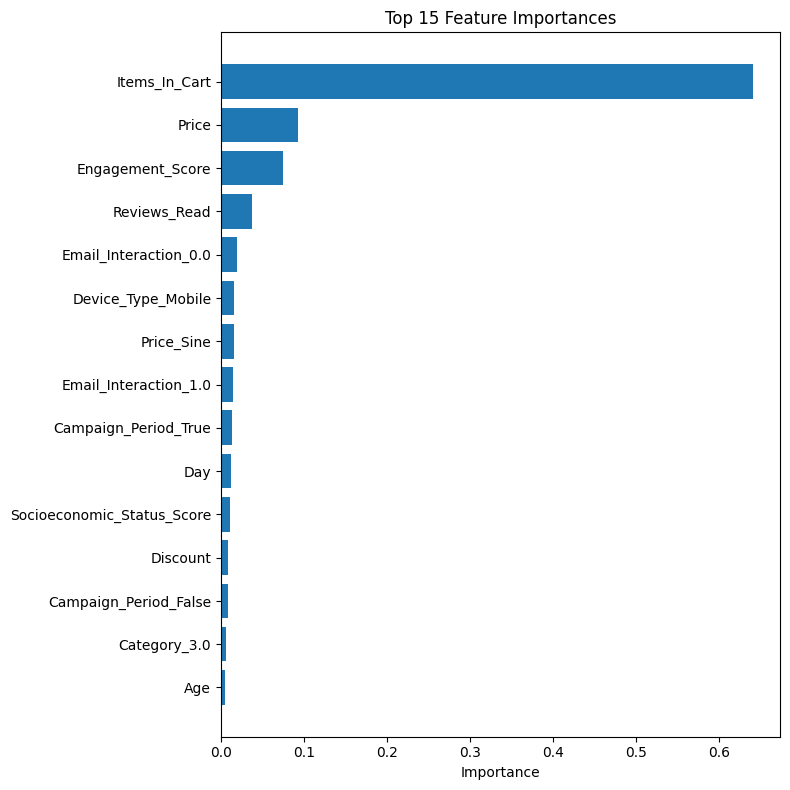

In [ ]:
# Get feature importances
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf_exp.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Important Features:")
print(feature_importance.head(15))

# Visualize
plt.figure(figsize=(8, 8))
plt.barh(feature_importance.head(15)['feature'], feature_importance.head(15)['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
# plt.savefig('barh.png')
plt.show()

#### Submit

In [ ]:
# Train full data set

# Fit on all training data
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X_full = train_df[feature_cols]
y_full = train_df['Purchase']
rf_exp.fit(X_full, y_full)

# Prepare test features (same columns as training)
X_test = test_df[feature_cols]

# Make predictions on test
test_predictions = rf_exp.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'Purchase': test_predictions
})

# Save to CSV
submission.to_csv('submission_exp_01.csv', index=False)

# Verify format
print(submission.head())
print(f"\nShape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nNull count: {submission.isnull().sum()}")
print(f"\nClass count: {submission['Purchase'].value_counts()}")
print(f"\nProportion of 1s: {submission['Purchase'].mean():.3f}")

   id  Purchase
0   1         0
1   2         1
2   3         0
3   4         1
4   5         0

Shape: (6269, 2)

Columns: ['id', 'Purchase']

Null count: id          0
Purchase    0
dtype: int64

Class count: Purchase
0    3477
1    2792
Name: count, dtype: int64

Proportion of 1s: 0.445


### Exp2: Median impute yes/no (0.73432)

#### Test

In [ ]:
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X = train_df[feature_cols]
y = train_df['Purchase']

# Baseline model
rf_exp = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=20,
    max_features=0.5,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1,
)

In [ ]:
run_clf(X, y, rf_exp)


=== Train F1 ===

Train F1-Score:  0.8189

=== Baseline Random Forest Results ===
Classification report train:
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      7147
           1       0.75      0.90      0.82      3837

    accuracy                           0.86     10984
   macro avg       0.85      0.87      0.85     10984
weighted avg       0.87      0.86      0.86     10984

Classification report val:
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      1788
           1       0.70      0.85      0.77       959

    accuracy                           0.82      2747
   macro avg       0.81      0.83      0.81      2747
weighted avg       0.84      0.82      0.83      2747


=== Cross-validation F1 ===

5-Fold CV F1-Score: 0.7812 (+/- 0.0100)

=== Prediction probability ===

Train: [0.28617159 0.61546955 0.62305692 ... 0.05825415 0.80590358 0.31394475]

Val: [0.78947976 0.63176

#### Submit

In [ ]:
# Train full data set

# Fit on all training data
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X_full = train_df[feature_cols]
y_full = train_df['Purchase']
rf_exp.fit(X_full, y_full)

# Prepare test features (same columns as training)
X_test = test_df[feature_cols]

# Make predictions on test
test_predictions = rf_exp.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'Purchase': test_predictions
})

# Save to CSV
submission.to_csv('submission_exp_02.csv', index=False)

# Verify format
print(submission.head())
print(f"\nShape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nNull count: {submission.isnull().sum()}")
print(f"\nClass count: {submission['Purchase'].value_counts()}")
print(f"\nProportion of 1s: {submission['Purchase'].mean():.3f}")

   id  Purchase
0   1         0
1   2         1
2   3         0
3   4         1
4   5         1

Shape: (6269, 2)

Columns: ['id', 'Purchase']

Null count: id          0
Purchase    0
dtype: int64

Class count: Purchase
0    3571
1    2698
Name: count, dtype: int64

Proportion of 1s: 0.430


### Exp3: One Hot Encoder vs Ordinal Encoder (0.73063)

#### Test

In [ ]:
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X = train_df[feature_cols]
y = train_df['Purchase']

# Baseline model
rf_exp = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=20,
    max_features=0.5,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1,
)

In [ ]:
run_clf(X, y, rf_exp)


=== Train F1 ===

Train F1-Score:  0.8200

=== Baseline Random Forest Results ===
Classification report train:
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      7147
           1       0.75      0.90      0.82      3837

    accuracy                           0.86     10984
   macro avg       0.85      0.87      0.85     10984
weighted avg       0.87      0.86      0.86     10984

Classification report val:
              precision    recall  f1-score   support

           0       0.91      0.81      0.85      1788
           1       0.70      0.85      0.77       959

    accuracy                           0.82      2747
   macro avg       0.80      0.83      0.81      2747
weighted avg       0.84      0.82      0.82      2747


=== Cross-validation F1 ===

5-Fold CV F1-Score: 0.7802 (+/- 0.0082)

=== Prediction probability ===

Train: [0.31419528 0.61818403 0.55454153 ... 0.04439009 0.83796375 0.26746571]

Val: [0.80859945 0.70521

#### Submit

In [ ]:
# Train full data set

# Fit on all training data
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X_full = train_df[feature_cols]
y_full = train_df['Purchase']
rf_exp.fit(X_full, y_full)

# Prepare test features (same columns as training)
X_test = test_df[feature_cols]

# Make predictions on test
test_predictions = rf_exp.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'Purchase': test_predictions
})

# Save to CSV
submission.to_csv('submission_exp_03.csv', index=False)

# Verify format
print(submission.head())
print(f"\nShape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nNull count: {submission.isnull().sum()}")
print(f"\nClass count: {submission['Purchase'].value_counts()}")
print(f"\nProportion of 1s: {submission['Purchase'].mean():.3f}")

   id  Purchase
0   1         0
1   2         1
2   3         0
3   4         1
4   5         1

Shape: (6269, 2)

Columns: ['id', 'Purchase']

Null count: id          0
Purchase    0
dtype: int64

Class count: Purchase
0    3539
1    2730
Name: count, dtype: int64

Proportion of 1s: 0.435


### Exp4: Add two simple Feature Engineering (0.72883)

#### Test

In [ ]:
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X = train_df[feature_cols]
y = train_df['Purchase']

# Baseline model
rf_exp = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=20,
    max_features=0.5,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1,
)

In [ ]:
run_clf(X, y, rf_exp)


=== Train F1 ===

Train F1-Score:  0.8180

=== Baseline Random Forest Results ===
Classification report train:
              precision    recall  f1-score   support

           0       0.94      0.84      0.89      7147
           1       0.75      0.90      0.82      3837

    accuracy                           0.86     10984
   macro avg       0.84      0.87      0.85     10984
weighted avg       0.87      0.86      0.86     10984

Classification report val:
              precision    recall  f1-score   support

           0       0.91      0.81      0.86      1788
           1       0.71      0.85      0.77       959

    accuracy                           0.82      2747
   macro avg       0.81      0.83      0.81      2747
weighted avg       0.84      0.82      0.83      2747


=== Cross-validation F1 ===

5-Fold CV F1-Score: 0.7808 (+/- 0.0104)

=== Prediction probability ===

Train: [0.31110095 0.62318005 0.57917883 ... 0.05863821 0.87244511 0.29822727]

Val: [0.76689981 0.70631

#### Submit

In [ ]:
# Train full data set

# Fit on all training data
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X_full = train_df[feature_cols]
y_full = train_df['Purchase']
rf_exp.fit(X_full, y_full)

# Prepare test features (same columns as training)
X_test = test_df[feature_cols]

# Make predictions on test
test_predictions = rf_exp.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'Purchase': test_predictions
})

# Save to CSV
submission.to_csv('submission_exp_04.csv', index=False)

# Verify format
print(submission.head())
print(f"\nShape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nNull count: {submission.isnull().sum()}")
print(f"\nClass count: {submission['Purchase'].value_counts()}")
print(f"\nProportion of 1s: {submission['Purchase'].mean():.3f}")

   id  Purchase
0   1         0
1   2         1
2   3         0
3   4         1
4   5         1

Shape: (6269, 2)

Columns: ['id', 'Purchase']

Null count: id          0
Purchase    0
dtype: int64

Class count: Purchase
0    3531
1    2738
Name: count, dtype: int64

Proportion of 1s: 0.437


### Exp5: RandomizedSearch (0.73377)

- RF reached the plateau since it saturated around 0.73-0.735

In [ ]:
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X_full = train_df[feature_cols]
y_full = train_df['Purchase']

# Prepare test features (same columns as training)
X_test = test_df[feature_cols]

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# parameter grid
param_dist = {
    'n_estimators': [200, 300, 400],
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [20, 30, 50],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 0.5],
    'class_weight': ['balanced_subsample']
}

rf_rnsearch = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='f1',
    random_state=SEED,
    n_jobs=-1,
    refit=True,
    verbose=2,
    return_train_score=True
)

rf_rnsearch.fit(X_full, y_full)

print(f"Best params: {rf_rnsearch.best_params_}")
print(f"Best CV F1: {rf_rnsearch.best_score_:.4f}")

# Use best model
best_rf = rf_rnsearch.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params: {'n_estimators': 200, 'min_samples_split': 30, 'min_samples_leaf': 5, 'max_features': 0.5, 'max_depth': 12, 'class_weight': 'balanced_subsample'}
Best CV F1: 0.7849


In [ ]:
# Extract best row

cv_results_df = pd.DataFrame(rf_rnsearch.cv_results_)
best_row = cv_results_df[cv_results_df['rank_test_score'] == 1]

print(f"\nShape: {cv_results_df.shape}")
print(f"\nBest row:{best_row}")

In [ ]:
# Train with best params from grid search on FULL data
best_rf.fit(X_full, y_full)

# Use default threshold (0.5)
test_predictions = best_rf.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'Purchase': test_predictions
})

# Save to CSV
submission.to_csv('submission_exp_05.csv', index=False)

# Verify format
print(submission.head())
print(f"\nShape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nNull count: {submission.isnull().sum()}")
print(f"\nClass count: {submission['Purchase'].value_counts()}")
print(f"\nProportion of 1s: {submission['Purchase'].mean():.3f}")

   id  Purchase
0   1         0
1   2         1
2   3         0
3   4         1
4   5         0

Shape: (6269, 2)

Columns: ['id', 'Purchase']

Null count: id          0
Purchase    0
dtype: int64

Class count: Purchase
0    3651
1    2618
Name: count, dtype: int64

Proportion of 1s: 0.418


## XGBoost

### Exp6: XGBoost (0.74447)

In [ ]:
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X_full = train_df[feature_cols]
y_full = train_df['Purchase']

# Prepare test features (same columns as training)
X_test = test_df[feature_cols]

# Verify test columns match train columns
assert list(X_full.columns) == list(X_test.columns)

In [ ]:
from xgboost import XGBClassifier

# Calculate scale_pos_weight for imbalance
scale_pos_weight = (y_full == 0).sum() / (y_full == 1).sum()

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=4,
    learning_rate=0.08,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.1,
    reg_lambda=2,
    reg_alpha=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist'   # fast GPU/CPU training
)

# Check CV score first
cv_scores = cross_val_score(xgb, X_full, y_full, cv=5, scoring='f1', n_jobs=-1)
print(f"XGBoost CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

XGBoost CV F1: 0.8007 (+/- 0.0055)


In [ ]:
# Fit on all training data
xgb.fit(X_full, y_full)

# Make predictions on test
test_predictions = xgb.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'Purchase': test_predictions
})

# Save to CSV
submission.to_csv('submission_exp_06.csv', index=False)

# Verify format
print(submission.head())
print(f"\nShape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nNull count: {submission.isnull().sum()}")
print(f"\nClass count: {submission['Purchase'].value_counts()}")
print(f"\nProportion of 1s: {submission['Purchase'].mean():.3f}")

   id  Purchase
0   1         0
1   2         1
2   3         0
3   4         1
4   5         0

Shape: (6269, 2)

Columns: ['id', 'Purchase']

Null count: id          0
Purchase    0
dtype: int64

Class count: Purchase
0    3678
1    2591
Name: count, dtype: int64

Proportion of 1s: 0.413


### Exp7: RandomizedSearch (0.74923)

In [ ]:
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X_full = train_df[feature_cols]
y_full = train_df['Purchase']

# Prepare test features (same columns as training)
X_test = test_df[feature_cols]

# Verify test columns match train columns
assert list(X_full.columns) == list(X_test.columns)

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [400, 500, 600],
    'max_depth':  [4, 5, 6],
    'learning_rate':  [0.04, 0.06, 0.08],
    'min_child_weight': [1, 2, 3],
    'subsample':  [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma':  [0, 0.05, 0.1, 0.2],
    'reg_lambda': [1, 2, 4],
    'reg_alpha':  [0, 0.1, 0.3],
    'scale_pos_weight': [1.7, 1.86, 2.0]
}

xgb_rnsearch = RandomizedSearchCV(
    XGBClassifier(random_state=SEED, tree_method='hist', n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='f1',
    random_state=SEED,
    n_jobs=-1,
    refit=True,
    verbose=2,
    return_train_score=True
)

xgb_rnsearch.fit(X_full, y_full)

print(f"Best params: {xgb_rnsearch.best_params_}")
print(f"Best CV F1: {xgb_rnsearch.best_score_:.4f}")

# Use best xgb model
best_xgb = xgb_rnsearch.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'subsample': 0.7, 'scale_pos_weight': 1.7, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 2, 'max_depth': 4, 'learning_rate': 0.04, 'gamma': 0.05, 'colsample_bytree': 0.7}
Best CV F1: 0.7990


In [ ]:
cv_results_df = pd.DataFrame(xgb_rnsearch.cv_results_)
best_row = cv_results_df[cv_results_df['rank_test_score'] == 1]

print(f"\nShape: {cv_results_df.shape}")
print(f"\nBest row:{best_row}")


Shape: (30, 26)

Best row:    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
13       1.934019       0.34743         0.142849        0.041211   

    param_subsample  param_scale_pos_weight  param_reg_lambda  \
13              0.7                     1.7                 2   

    param_reg_alpha  param_n_estimators  param_min_child_weight  \
13              0.1                 500                       2   

    param_max_depth  param_learning_rate  param_gamma  param_colsample_bytree  \
13                4                 0.04         0.05                     0.7   

                                               params  split0_test_score  \
13  {'subsample': 0.7, 'scale_pos_weight': 1.7, 'r...           0.801989   

    split1_test_score  split2_test_score  mean_test_score  std_test_score  \
13           0.792419            0.80267         0.799026         0.00468   

    rank_test_score  split0_train_score  split1_train_score  \
13                1            0.861

In [ ]:
# Train with best params from grid search on FULL data
best_xgb.fit(X_full, y_full)

# Use default threshold (0.5)
test_predictions = best_xgb.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'Purchase': test_predictions
})

# Save to CSV
submission.to_csv('submission_exp_07.csv', index=False)

# Verify format
print(submission.head())
print(f"\nShape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nNull count: {submission.isnull().sum()}")
print(f"\nClass count: {submission['Purchase'].value_counts()}")
print(f"\nProportion of 1s: {submission['Purchase'].mean():.3f}")

   id  Purchase
0   1         0
1   2         1
2   3         0
3   4         1
4   5         0

Shape: (6269, 2)

Columns: ['id', 'Purchase']

Null count: id          0
Purchase    0
dtype: int64

Class count: Purchase
0    3635
1    2634
Name: count, dtype: int64

Proportion of 1s: 0.420


### Exp8: Informed Search + RandomizedSearch (0.74901)
- XGBoost reached the plateau since mirco-tuned XGBoost didn't buy anything meaningful

In [ ]:
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X_full = train_df[feature_cols]
y_full = train_df['Purchase']

# Prepare test features (same columns as training)
X_test = test_df[feature_cols]

# Verify test columns match train columns
assert list(X_full.columns) == list(X_test.columns)

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [450, 500, 550],
    'max_depth':  [4, 5],
    'learning_rate':  [0.035, 0.04, 0.045],
    'min_child_weight': [1, 2, 3],
    'subsample':  [0.7, 0.8],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'gamma':  [0, 0.05, 0.1],
    'reg_lambda': [1.5, 2, 3],
    'reg_alpha':  [0, 0.1, 0.2],
    'scale_pos_weight': [1.6, 1.7, 1.8]
}

xgb_ifsearch = RandomizedSearchCV(
    XGBClassifier(random_state=SEED, tree_method='hist', n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring='f1',
    random_state=SEED,
    n_jobs=-1,
    refit=True,
    verbose=2,
    return_train_score=True
)

xgb_ifsearch.fit(X_full, y_full)

print(f"Best params: {xgb_ifsearch.best_params_}")
print(f"Best CV F1: {xgb_ifsearch.best_score_:.4f}")

# Use best xgb model
best_xgb = xgb_ifsearch.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best params: {'subsample': 0.7, 'scale_pos_weight': 1.8, 'reg_lambda': 3, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.045, 'gamma': 0, 'colsample_bytree': 0.8}
Best CV F1: 0.8011


In [ ]:
cv_results_df = pd.DataFrame(xgb_ifsearch.cv_results_)
best_row = cv_results_df[cv_results_df['rank_test_score'] == 1]

print(f"\nShape: {cv_results_df.shape}")
print(f"\nBest row:{best_row}")


Shape: (30, 26)

Best row:    mean_fit_time  std_fit_time  mean_score_time  std_score_time  \
15       1.593356       0.00461         0.084166        0.001052   

    param_subsample  param_scale_pos_weight  param_reg_lambda  \
15              0.7                     1.8               3.0   

    param_reg_alpha  param_n_estimators  param_min_child_weight  ...  \
15              0.1                 500                       3  ...   

    split1_test_score  split2_test_score  mean_test_score  std_test_score  \
15           0.793063           0.805987         0.801076        0.005714   

   rank_test_score  split0_train_score  split1_train_score  \
15               1            0.865259            0.871443   

    split2_train_score  mean_train_score  std_train_score  
15            0.870088           0.86893         0.002654  

[1 rows x 26 columns]


In [ ]:
# Train with best params from grid search on FULL data
best_xgb.fit(X_full, y_full)

# Use default threshold (0.5)
test_predictions = best_xgb.predict(X_test)

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'Purchase': test_predictions
})

# Save to CSV
submission.to_csv('submission_exp_08.csv', index=False)

# Verify format
print(submission.head())
print(f"\nShape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nNull count: {submission.isnull().sum()}")
print(f"\nClass count: {submission['Purchase'].value_counts()}")
print(f"\nProportion of 1s: {submission['Purchase'].mean():.3f}")

   id  Purchase
0   1         0
1   2         1
2   3         0
3   4         1
4   5         0

Shape: (6269, 2)

Columns: ['id', 'Purchase']

Null count: id          0
Purchase    0
dtype: int64

Class count: Purchase
0    3617
1    2652
Name: count, dtype: int64

Proportion of 1s: 0.423


### Exp9: Threshold tuning (0.74966)

In [ ]:
best_xgb = XGBClassifier(
    n_estimators=500,
    min_child_weight=3,
    max_depth=4,
    learning_rate=0.045,
    subsample=0.7,
    reg_lambda=3,
    reg_alpha=0.1,
    gamma=0,
    colsample_bytree=0.8,
    scale_pos_weight=1.8,
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist'   # fast GPU/CPU training
)

In [ ]:
from sklearn.model_selection import cross_val_predict

# Predict probabilities on train set
train_pred_proba = cross_val_predict(
    best_xgb,
    X_full,
    y_full,
    cv=5,
    method='predict_proba',
    n_jobs=-1,
)[:,1]

In [ ]:
# Tune thresholds from 0.1 to 0.9

thresholds = np.arange(0.1, 0.9, 0.01)
scores = []

for t in thresholds:
  preds = (train_pred_proba >= t).astype(int)
  scores.append(f1_score(y_full, preds))

best_t = thresholds[np.argmax(scores)]
best_score = max(scores)

print(f"Best threshold: {best_t}")
print(f"\nBest score: {best_score}")

Best threshold: 0.5199999999999998

Best score: 0.800587084148728


In [ ]:
# Train with best params from grid search on FULL data
best_xgb.fit(X_full, y_full)

# Predict test with best t
test_pred_proba = best_xgb.predict_proba(X_test)[:,1]
test_predictions = (test_pred_proba >= best_t).astype(int)

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'Purchase': test_predictions
})

# Save to CSV
submission.to_csv('submission_exp_09.csv', index=False)

# Verify format
print(submission.head())
print(f"\nShape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nNull count: {submission.isnull().sum()}")
print(f"\nClass count: {submission['Purchase'].value_counts()}")
print(f"\nProportion of 1s: {submission['Purchase'].mean():.3f}")

   id  Purchase
0   1         0
1   2         1
2   3         0
3   4         1
4   5         0

Shape: (6269, 2)

Columns: ['id', 'Purchase']

Null count: id          0
Purchase    0
dtype: int64

Class count: Purchase
0    3683
1    2586
Name: count, dtype: int64

Proportion of 1s: 0.413


## Ensemble (RF + XGB)

### Exp10: Wieght & threshold tuning (0.75158)

In [ ]:
feature_cols = [col for col in train_df.columns if col not in ['id', 'Session_ID', 'Purchase']]
X_full = train_df[feature_cols]
y_full = train_df['Purchase']

# Prepare test features (same columns as training)
X_test = test_df[feature_cols]

# Verify test columns match train columns
assert list(X_full.columns) == list(X_test.columns)

In [ ]:
# Best RF model
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=30,
    min_samples_leaf=5,
    max_features=0.5,
    class_weight='balanced_subsample',
    random_state=SEED,
    n_jobs=-1,
)

# Best XGB model
best_xgb = XGBClassifier(
    n_estimators=500,
    min_child_weight=3,
    max_depth=4,
    learning_rate=0.045,
    subsample=0.7,
    reg_lambda=3,
    reg_alpha=0.1,
    gamma=0,
    colsample_bytree=0.8,
    scale_pos_weight=1.8,
    random_state=SEED,
    n_jobs=-1,
    tree_method='hist'   # fast GPU/CPU training
)

In [ ]:
# OOF probabilities for RF
oof_rf = cross_val_predict(
    best_rf,
    X_full,
    y_full,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

# OOF probabilities for XGB
oof_xgb = cross_val_predict(
    best_xgb,
    X_full,
    y_full,
    cv=5,
    method='predict_proba',
    n_jobs=-1
)[:, 1]

In [ ]:
# Tune weights from 0.5 to 0.9 (step 0.5)
# XGB gets w, RF gets (1-W)
weights = np.arange(0.5, 0.95, 0.05)
results = []

# Use default threshould to tune weights
for w in weights:
  blend = w * oof_xgb + (1-w) * oof_rf
  preds = (blend >= 0.5).astype(int)
  f1 = f1_score(y_full, preds)
  results.append(f1)
  print(f"w={w:.2f}, F1={f1:.5f}")

best_w = weights[np.argmax(results)]
best_w_score = max(results)

print(f"Best weight: {best_w}")
print(f"Best F1 score: {best_w_score}")

w=0.50, F1=0.79433
w=0.55, F1=0.79445
w=0.60, F1=0.79533
w=0.65, F1=0.79684
w=0.70, F1=0.79676
w=0.75, F1=0.79691
w=0.80, F1=0.79815
w=0.85, F1=0.79896
w=0.90, F1=0.79942

Best weight: 0.9000000000000004
Best F1 score: 0.7994205697730565


- Best weights: `p_blend = 0.9 * p_XGB + 0.1 * p_RF`

In [ ]:
# Use best weighs to tune threshold
best_w = 0.9
blend_oof = best_w * oof_xgb + (1 - best_w) * oof_rf

# Tune threshold from 0.1 to 0.9 (step 0.01)
thresholds = np.arange(0.1, 0.9, 0.01)
scores = []

for t in thresholds:
  preds = (blend_oof >= t).astype(int)
  scores.append(f1_score(y_full, preds))

best_t = thresholds[np.argmax(scores)]
best_score = max(scores)

print(f"Best threshold: {best_t}")
print(f"Best blended F1: {best_score}")

Best threshold: 0.5499999999999998
Best blended F1: 0.8003191701575902


In [ ]:
# Train on FULL data
best_xgb.fit(X_full, y_full)
best_rf.fit(X_full, y_full)

# Predict test with best t
xgb_test_pred_proba = best_xgb.predict_proba(X_test)[:,1]
rf_test_pred_proba = best_rf.predict_proba(X_test)[:,1]
blend_xgb_rf = best_w * xgb_test_pred_proba + (1 - best_w) * rf_test_pred_proba
test_predictions = (blend_xgb_rf >= best_t).astype(int)

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'Purchase': test_predictions
})

# Save to CSV
submission.to_csv('submission_exp_10.csv', index=False)

# Verify format
print(submission.head())
print(f"\nShape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nNull count: {submission.isnull().sum()}")
print(f"\nClass count: {submission['Purchase'].value_counts()}")
print(f"\nProportion of 1s: {submission['Purchase'].mean():.3f}")

   id  Purchase
0   1         0
1   2         1
2   3         0
3   4         1
4   5         0

Shape: (6269, 2)

Columns: ['id', 'Purchase']

Null count: id          0
Purchase    0
dtype: int64

Class count: Purchase
0    3781
1    2488
Name: count, dtype: int64

Proportion of 1s: 0.397


### Exp11: Informed tuning on wieght & threshold (0.75178)

In [ ]:
# Fine–tune weights at best region (step 0.01)
# XGB gets w, RF gets (1-W)
weights = np.arange(0.88, 0.93, 0.01)
results = []

# Use default threshould to tune weights
for w in weights:
  blend = w * oof_xgb + (1-w) * oof_rf
  preds = (blend >= 0.5).astype(int)
  f1 = f1_score(y_full, preds)
  results.append(f1)
  print(f"w={w:.2f}, F1={f1:.5f}")

best_w = weights[np.argmax(results)]
best_w_score = max(results)

print(f"Best weight: {best_w}")
print(f"Best F1 score: {best_w_score}")

w=0.88, F1=0.79946
w=0.89, F1=0.79977
w=0.90, F1=0.79942
w=0.91, F1=0.79950
w=0.92, F1=0.79930
w=0.93, F1=0.79938
Best weight: 0.89
Best F1 score: 0.799768295037652


- Best weights: `p_blend = 0.89 * p_XGB + 0.11 * p_RF`

In [ ]:
# Fine-grained threshold tuning
best_w = 0.89
blend_oof = best_w * oof_xgb + (1 - best_w) * oof_rf

# Tune threshold from 0.1 to 0.9 (step 0.001)
thresholds = np.arange(0.5, 0.6, 0.001)
scores = []

for t in thresholds:
  preds = (blend_oof >= t).astype(int)
  scores.append(f1_score(y_full, preds))

best_t = thresholds[np.argmax(scores)]
best_score = max(scores)

print(f"Best threshold: {best_t}")
print(f"Best blended F1: {best_score}")

Best threshold: 0.532
Best blended F1: 0.8003550996251726


In [ ]:
# Train on FULL data
best_xgb.fit(X_full, y_full)
best_rf.fit(X_full, y_full)

# Predict test with best t
xgb_test_pred_proba = best_xgb.predict_proba(X_test)[:,1]
rf_test_pred_proba = best_rf.predict_proba(X_test)[:,1]
blend_xgb_rf = best_w * xgb_test_pred_proba + (1 - best_w) * rf_test_pred_proba
test_predictions = (blend_xgb_rf >= best_t).astype(int)

# Create submission file
submission = pd.DataFrame({
    'id': test_df['id'],
    'Purchase': test_predictions
})

# Save to CSV
submission.to_csv('submission_exp_11.csv', index=False)

# Verify format
print(submission.head())
print(f"\nShape: {submission.shape}")
print(f"\nColumns: {submission.columns.tolist()}")
print(f"\nNull count: {submission.isnull().sum()}")
print(f"\nClass count: {submission['Purchase'].value_counts()}")
print(f"\nProportion of 1s: {submission['Purchase'].mean():.3f}")

   id  Purchase
0   1         0
1   2         1
2   3         0
3   4         1
4   5         0

Shape: (6269, 2)

Columns: ['id', 'Purchase']

Null count: id          0
Purchase    0
dtype: int64

Class count: Purchase
0    3727
1    2542
Name: count, dtype: int64

Proportion of 1s: 0.405


# Kaggle Submissions Summary

## Random Forest

Baseline: 0.72618

After tuning: 0.73377

## XGBoost

Baseline: 0.74447

After RandomizedSearch: 0.74923

After threshold tuning: 0.74966

## Ensemble (RF + XGB)

Final (Informed tuning): 0.75178

### Archived Experiments: Ordinal Encoder & simple Feature Engineering (not used in final model)

In [ ]:
# # Step 4
# # Encode Categorical Variables

# # Ensure all categorical columns are of string type before encoding
# for col in cat_cols:
#     train_df[col] = train_df[col].astype(str)
#     test_df[col] = test_df[col].astype(str)

# # Fit on train, transform both
# oe = OrdinalEncoder(categories='auto', handle_unknown='use_encoded_value', unknown_value=-1)
# oe.fit(train_df[cat_cols])

# train_df[cat_cols] = oe.transform(train_df[cat_cols])
# test_df[cat_cols] = oe.transform(test_df[cat_cols])

In [ ]:
# # Step 5
# # Simple feature engineering

# # 1. Items in cart grater than zero
# train_df['Items_In_Cart_gt0'] = (train_df['Items_In_Cart'] > 0).astype(int)
# test_df['Items_In_Cart_gt0'] = (test_df['Items_In_Cart'] > 0).astype(int)

# # 2. Engagement score grater than zero
# train_df['Engagement_Score_gt0'] = (train_df['Engagement_Score'] > 0).astype(int)
# test_df['Engagement_Score_gt0'] = (test_df['Engagement_Score'] > 0).astype(int)